**Daily Challenge: Stock Price Prediction with LSTM**


Objectifs 🇰

La prédiction des prix des actions est un problème de séries temporelles, où l'ordre des données est crucial. Les réseaux LSTM (Long Short-Term Memory) sont une architecture de réseaux de neurones récurrents (RNN) spécialement conçue pour gérer les dépendances à long terme dans les séquences de données, ce qui les rend idéaux pour ce type de tâche.

Ce défi permettra de :

* Maîtriser le prétraitement des séries temporelles, une compétence distincte du traitement d'images ou de données tabulaires.

* Plonger dans PyTorch, un framework puissant et flexible, très prisé dans la recherche et l'industrie.

* Évaluer un modèle de régression, avec une métrique comme le R2, différente de l'exactitude pour la classification.

1. Install Required Libraries

In [1]:
# 1. Install Required Libraries

# For Google Colab, many are pre-installed.
# If running locally, you might need to install them.

# Make sure you have pip installed and updated
# python -m pip install --upgrade pip

# Install PyTorch (ensure you select the correct version for your system if local)
# For Colab, a recent version is usually available.
# Example for CPU only: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# Install other necessary libraries
# Note: gensim and spacy are more for NLP tasks, they might be included for broader context but may not be strictly used for stock prediction in this challenge.
# I'll include them for completeness as per instructions, but focus on the core ones for the task.

try:
    import torch
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from sklearn.preprocessing import MinMaxScaler
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score
    print("All core libraries imported successfully.")
except ImportError as e:
    print(f"Error importing a library: {e}")
    print("Please install the missing libraries. Example commands:")
    print("pip install torch torchvision torchaudio") # Adjust for specific hardware if needed (e.g., --index-url for CPU/CUDA)
    print("pip install numpy pandas scikit-learn")
    print("pip install gensim spacy") # Optional, depending on actual use in the challenge

# Verify PyTorch version and available device
if torch.cuda.is_available():
    print(f"PyTorch version: {torch.__version__} (CUDA available)")
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
else:
    print(f"PyTorch version: {torch.__version__} (CUDA not available, using CPU)")

# Set default device (CPU or CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

All core libraries imported successfully.
PyTorch version: 2.6.0+cu124 (CUDA not available, using CPU)
Using device: cpu


2. Load and Preprocess the Dataset

In [3]:
# 2. Load and Preprocess the Dataset

try:
    df = pd.read_csv('/content/stock_market_dataset.csv')
    print("Dataset loaded successfully.")
    print(df.head())
    print(df.info())
except FileNotFoundError:
    print("Error: 'stock_market_dataset' not found.")
    print("Please upload your stock market dataset CSV file to your Colab environment or specify the correct path.")
    print("For demonstration, creating a dummy DataFrame.")
    # Create a dummy DataFrame if the file is not found, for demonstration purposes
    data = {
        'Date': pd.to_datetime(pd.date_range(start='2020-01-01', periods=100, freq='D')),
        'Open': np.random.rand(100) * 100 + 100,
        'High': np.random.rand(100) * 100 + 110,
        'Low': np.random.rand(100) * 100 + 90,
        'Close': np.random.rand(100) * 100 + 100,
        'Volume': np.random.randint(100000, 500000, 100)
    }
    df = pd.DataFrame(data)
    print("\nDummy DataFrame created for demonstration:")
    print(df.head())


# Drop unnecessary columns (e.g., 'Date', 'Open', 'High', 'Low', 'Volume' if only 'Close' is used)
# For simplicity, let's use only the 'Close' price for prediction.
# You can include other features later if you want a multivariate LSTM.
data_to_use = df[['close']].values # Convert to numpy array

# Create a target column for the next day’s closing price.
# This means for each day, the feature will be its 'Close' price, and the target will be the 'Close' price of the *next* day.
# We shift the 'Close' column up by one and drop the last row (which won't have a next day price).
# The last row of features will have no corresponding next_day_close, so it's dropped.
# The first row of next_day_close will correspond to the second day's close price.
X = data_to_use[:-1] # All data except the last day's close for features
y = data_to_use[1:]  # All data except the first day's close for targets (i.e., next day's close)

print(f"\nOriginal data shape: {data_to_use.shape}")
print(f"Features (X) shape before scaling: {X.shape}")
print(f"Target (y) shape before scaling: {y.shape}")

# Normalize the dataset using MinMaxScaler.
# It's crucial to fit the scaler ONLY on the training data later to avoid data leakage.
# For now, we'll initialize it.
scaler = MinMaxScaler(feature_range=(0, 1))

# We'll apply fitting and transforming to train/test sets separately in the next step.
# For now, let's keep X and y unscaled, as the instructions for MinMaxScaler are under "Prepare the Dataset for Training".
# If the instruction meant to scale ALL data now, we'd do:
# data_scaled = scaler.fit_transform(data_to_use)
# X = data_scaled[:-1]
# y = data_scaled[1:]
# But it's safer to fit only on training data.

print("\nDataset loaded and initial features/target prepared.")

Dataset loaded successfully.
           unix        date    symbol    open    high     low   close  \
0  1.640560e+12  12-27-2021  XRP-USDT  0.9200  0.9237  0.9200  0.9226   
1  1.640480e+12  12-26-2021  XRP-USDT  0.9252  0.9334  0.9052  0.9200   
2  1.640390e+12  12-25-2021  XRP-USDT  0.9114  0.9350  0.8981  0.9252   
3  1.640300e+12  12-24-2021  XRP-USDT  0.9941  0.9966  0.8964  0.9115   
4  1.640220e+12  12-23-2021  XRP-USDT  0.9538  1.0167  0.9372  0.9941   

    Volume XRP   Volume USDT  
0    2384512.0  2.198450e+06  
1  163438501.0  1.499400e+08  
2  250074945.0  2.302303e+08  
3  567234092.0  5.377035e+08  
4  479436230.0  4.729372e+08  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1334 entries, 0 to 1333
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unix         1334 non-null   float64
 1   date         1334 non-null   object 
 2   symbol       1334 non-null   object 
 3   open         1334 non-nul

1.   Dataset loaded successfully

2.   df.head() Output

Les colonnes sont unix, date, symbol, open, high, low, close, Volume XRP, Volume USDT. Toutes semblent avoir le format attendu pour des données de marché.

3.   df.info() Output

RangeIndex: 1334 entries, 0 to 1333: Confirme que le dataset contient 1334 enregistrements (probablement 1334 jours de données). C'est une bonne taille pour un premier modèle LSTM.

Data columns (total 9 columns):: confirme le nombre de colonnes et leurs noms/types.

Non-Null Count: toutes les colonnes ont 1334 entrées non-nulles, ce qui est excellent. Cela signifie qu'il n'y a pas de valeurs manquantes (NaN) dans votre dataset, ce qui simplifie grandement le prétraitement.

Dtype: les types de données sont appropriés : float64 pour les prix et volumes (qui sont numériques), et object pour la date et le symbole. La colonne date devra être convertie en datetime si utilisée pour trier ou manipuler des dates. La colonne unix est déjà un float64, représentant probablement un timestamp, et est une alternative à la colonne date.


4. Original data shape: (1334, 1)

Cela indique que la variable data_to_use contient 1334 observations et 1 seule caractéristique (la colonne 'close' que vous avez sélectionnée). C'est parfaitement en ligne avec l'objectif de base qui est de prédire en utilisant uniquement le prix de clôture.


5. Features (X) shape before scaling: (1333, 1)


6. Target (y) shape before scaling: (1333, 1)

C'est la confirmation que la logique de préparation des données pour la prédiction t rightarrowt+1 a fonctionné correctement.

Ayant 1334 jours, la création des paires (jour actuel, jour suivant) résulte en 1333 paires, car le dernier jour n'a pas de "jour suivant" dans le dataset. C'est le comportement attendu et correct.


7. Dataset loaded and initial features/target prepared.

Ce message final confirme que toutes les opérations de la partie 2 ont été exécutées sans erreur.


**Conclusion pour la Partie 2 :**
Fait :

Chargé le bon jeu de données.

Confirmé l'absence de valeurs manquantes.

Sélectionné la colonne 'close' comme caractéristique principale.

Préparé les paires features/target avec un décalage d'un jour, ce qui est fondamental pour la prédiction de séries temporelles avec un modèle LSTM.

**3. Prepare the Dataset for Training**

In [4]:
# 3. Prepare the Dataset for Training

# Split the dataset into training, validation, and testing sets.
# Common splits: 70% train, 15% validation, 15% test, chronologically.

train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

train_X, train_y = X[0:train_size,:], y[0:train_size,:]
val_X, val_y = X[train_size:train_size+val_size,:], y[train_size:train_size+val_size,:]
test_X, test_y = X[train_size+val_size:len(X),:], y[train_size+val_size:len(X),:]

print(f"\n--- Dataset Split Sizes ---")
print(f"Train set size: {len(train_X)}")
print(f"Validation set size: {len(val_X)}")
print(f"Test set size: {len(test_X)}")

# Normalize the dataset using MinMaxScaler.
# Fit scaler ONLY on training data to prevent data leakage from validation/test sets.
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1)) # If target needs separate scaling

train_X_scaled = scaler_X.fit_transform(train_X)
train_y_scaled = scaler_y.fit_transform(train_y) # Scale target separately

val_X_scaled = scaler_X.transform(val_X)
val_y_scaled = scaler_y.transform(val_y)

test_X_scaled = scaler_X.transform(test_X)
test_y_scaled = scaler_y.transform(test_y)

# LSTMs typically expect input in the shape (batch_size, sequence_length, num_features).
# Here, our 'sequence_length' is 1 for now (predict next day from current day).
# If we wanted to predict next day from *last N days*, sequence_length would be N.
# Let's define a function to create sequences for LSTM.

def create_sequences(input_data, target_data, sequence_length):
    xs, ys = [], []
    for i in range(len(input_data) - sequence_length):
        x = input_data[i:(i + sequence_length)]
        y = target_data[i + sequence_length] # Predict the value *after* the sequence
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Define sequence length (e.g., use the last 10 days to predict the next day)
# For now, let's stick to sequence_length=1 for simplicity if data is already (N, 1) and target is (N, 1)
# However, for a true LSTM, it's better to have sequences.
# Let's set a common sequence length, e.g., 5 or 10.
SEQUENCE_LENGTH = 10 # Predict next day's price based on the last 10 days' prices.

train_X_sequences, train_y_sequences = create_sequences(train_X_scaled, train_y_scaled, SEQUENCE_LENGTH)
val_X_sequences, val_y_sequences = create_sequences(val_X_scaled, val_y_scaled, SEQUENCE_LENGTH)
test_X_sequences, test_y_sequences = create_sequences(test_X_scaled, test_y_scaled, SEQUENCE_LENGTH)

print(f"\n--- Data shapes after sequencing (sequence_length={SEQUENCE_LENGTH}) ---")
print(f"train_X_sequences shape: {train_X_sequences.shape}") # (num_samples, sequence_length, num_features)
print(f"train_y_sequences shape: {train_y_sequences.shape}") # (num_samples, num_features_target)


# Create a custom PyTorch Dataset class to handle the data.
class StockDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        # Convert numpy arrays to PyTorch tensors
        # Ensure data types are float32 for model training
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Use DataLoader to create iterable datasets for training and evaluation.
BATCH_SIZE = 16 # Adjust batch size as needed

train_dataset = StockDataset(train_X_sequences, train_y_sequences)
val_dataset = StockDataset(val_X_sequences, val_y_sequences)
test_dataset = StockDataset(test_X_sequences, test_y_sequences)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) # Shuffle for time series should be False
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders created with batch size: {BATCH_SIZE}")
# Example of one batch
for batch_X, batch_y in train_loader:
    print(f"Example batch X shape: {batch_X.shape}") # (BATCH_SIZE, SEQUENCE_LENGTH, NUM_FEATURES)
    print(f"Example batch y shape: {batch_y.shape}") # (BATCH_SIZE, NUM_FEATURES_TARGET)
    break



--- Dataset Split Sizes ---
Train set size: 933
Validation set size: 199
Test set size: 201

--- Data shapes after sequencing (sequence_length=10) ---
train_X_sequences shape: (923, 10, 1)
train_y_sequences shape: (923, 1)

DataLoaders created with batch size: 16
Example batch X shape: torch.Size([16, 10, 1])
Example batch y shape: torch.Size([16, 1])



Analyse des résultats de la partie 3 : préparation du jeu de données


1. Répartition des jeux de données

> Train set size: 933

> Validation set size: 199

> Test set size: 201

C'est parfait. Avec un total de 1333 points de données (après la création des paires X,y décalées), la répartition 70%/15%/15% est bien respectée. La division chronologique est cruciale pour les séries temporelles, et ces tailles indiquent que le découpage a été effectué correctement.


2. Formes des données après séquençage

> train_X_sequences shape: (923, 10, 1)

> train_y_sequences shape: (923, 1)

Ces formes sont exactement ce qu'on attendait pour l'entrée d'un modèle LSTM :

(> 923, 10, 1) pour train_X_sequences:

>> 923 est le nombre d'échantillons d'entraînement après la création des séquences. Puisque chaque séquence nécessite SEQUENCE_LENGTH (ici 10) jours, SEQUENCE_LENGTH éléments sont au début de notre ensemble d'entraînement pour former les premières séquences. Donc, 933−10=923. C'est correct.

>> 10 est SEQUENCE_LENGTH, ce qui signifie que chaque échantillon d'entraînement est une séquence de 10 jours consécutifs.

>> 1 est le nombre de caractéristiques par jour (ici, le prix de clôture 'close' uniquement).
C'est le format parfait (batch_size, sequence_length, num_features) pour la couche LSTM.


> (923, 1) pour train_y_sequences:

>> 923 correspond aux 923 séquences d'entraînement.

>> 1 est la valeur cible à prédire pour chaque séquence (le prix de clôture du jour suivant la séquence de 10 jours).


3. Chargeurs de données PyTorch (DataLoaders)

> DataLoaders created with batch size: 16

> Example batch X shape: torch.Size([16, 10, 1])

> Example batch y shape: torch.Size([16, 1])

Ceci confirme que les DataLoaders ont été correctement configurés. Lors de l'entraînement, notre modèle recevra des lots de 16 séquences à la fois. Chaque lot X aura la forme (16, 10, 1) et le lot y correspondant aura la forme (16, 1). C'est le format idéal pour l'entraînement par lots avec PyTorch.

Tout le processus de prétraitement et de préparation des données pour l'LSTM a été effectué avec succès. Les spécificités des séries temporelles (division chronologique, création de séquences) et la conversion en tenseurs PyTorch via les Dataset et DataLoader  ont bien géré.

4. Define the LSTM Model

In [5]:
# 4. Define the LSTM Model

class StockPredictor(torch.nn.Module):
    def __init__(self, input_size, hidden_layer_size, num_layers, output_size, dropout_rate=0.2):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        # LSTM layer (or GRU, let's use LSTM as it's the challenge title)
        # batch_first=True means input/output tensors are (batch_size, seq_len, features)
        self.lstm = torch.nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)

        # Dropout layer (applied after LSTM, or can be within LSTM if num_layers > 1)
        self.dropout = torch.nn.Dropout(dropout_rate)

        # Fully connected layer for output
        self.linear = torch.nn.Linear(hidden_layer_size, output_size)

        # Initialize hidden and cell states (optional, LSTM can handle it internally if not provided)
        # self.hidden_cell = (torch.zeros(num_layers, batch_size, self.hidden_layer_size).to(device),
        #                     torch.zeros(num_layers, batch_size, self.hidden_layer_size).to(device))

    def forward(self, input_seq):
        # input_seq shape: (batch_size, sequence_length, input_size)

        # LSTM output:
        # output (seq_len, batch, num_directions * hidden_size): tensor containing the output features (h_t) from the last layer of the LSTM, for each t.
        # hidden_cell (h_n, c_n): h_n (num_layers * num_directions, batch, hidden_size) contains the final hidden state for each layer.
        # c_n (num_layers * num_directions, batch, hidden_size) contains the final cell state for each layer.


                # Pass through LSTM layer
        # For simplicity, we don't manually manage hidden_cell state across batches here,
        # relying on PyTorch's default behavior or stateless LSTM for sequence processing.
        lstm_out, (hidden_state, cell_state) = self.lstm(input_seq) # hidden_cell is initialized internally if not passed

        # Take the output of the last time step for the prediction
        # lstm_out[:, -1, :] gets the output of the last element in the sequence for all batches
        last_time_step_output = lstm_out[:, -1, :] # Shape: (batch_size, hidden_layer_size)

        # Apply dropout
        dropout_out = self.dropout(last_time_step_output)

        # Pass through linear layer
        predictions = self.linear(dropout_out)

        return predictions

# --- Model Parameters ---
INPUT_SIZE = train_X_sequences.shape[2] # Number of features per time step (here, 1 for 'Close' price)
HIDDEN_LAYER_SIZE = 64 # Number of units in the LSTM hidden layer
NUM_LAYERS = 2 # Number of stacked LSTM layers
OUTPUT_SIZE = train_y_sequences.shape[1] # Number of output features (here, 1 for 'Next Close' price)
DROPOUT_RATE = 0.2 # Dropout rate for regularization

# Create an instance of the model and move it to the defined device (CPU/GPU)
model = StockPredictor(INPUT_SIZE, HIDDEN_LAYER_SIZE, NUM_LAYERS, OUTPUT_SIZE, DROPOUT_RATE).to(device)

print(f"\n--- LSTM Model Architecture ---")
print(model)
# Count trainable parameters (optional)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")



--- LSTM Model Architecture ---
StockPredictor(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)
Total trainable parameters: 50497


**Analyse de la partie 4 : définition du modèle LSTM**


Notre architecture LSTM est correctement définie :

* StockPredictor: c'est le nom de la classe de votre modèle, et elle contient bien les couches que vous avez spécifiées.

* (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2):

> 1: c'est input_size, le nombre de caractéristiques par pas de temps dans votre séquence (ici, le prix de clôture unique). C'est correct.

> 64: c'est hidden_layer_size, le nombre d'unités (neurones) dans la couche cachée de l'LSTM. C'est une taille standard qui devrait bien fonctionner pour ce problème.

> num_layers=2: le modèle utilise deux couches LSTM empilées, ce qui permet d'apprendre des représentations plus complexes des données séquentielles.

> batch_first=True: indique que nos tenseurs d'entrée (batch_X_sequences) sont au format (batch_size, sequence_length, num_features), ce qui est le standard le plus intuitif et que nous avons préparé.

> dropout=0.2: un taux de dropout de 20% est appliqué entre les couches LSTM (car num_layers > 1). C'est une bonne technique de régularisation pour prévenir le surapprentissage.


* (dropout): Dropout(p=0.2, inplace=False):

> C'est la couche de dropout séparée que vous avez ajoutée après la couche LSTM, appliquée à la sortie du dernier pas de temps de l'LSTM. Un taux de 20% est approprié ici aussi.


* (linear): Linear(in_features=64, out_features=1, bias=True):

> C'est la couche de sortie (dense). in_features=64 correspond à la taille de la couche cachée de l'LSTM (après le dropout).

> out_features=1 signifie que le modèle prédira une seule valeur (le prix de clôture du jour suivant). C'est correct pour notre tâche de régression.


* Total trainable parameters: 50497:

> Ce nombre de paramètres est tout à fait raisonnable pour un modèle de cette taille. Ce n'est pas un modèle gigantesque, ce qui est bien pour commencer et pour un entraînement relativement rapide.

**5. Train the Model**


L'entraînement d'un modèle PyTorch implique une boucle d'entraînement où nous itérons sur les données, effectuons des passes avant et arrière, et mettez à jour les poids.


--- Starting Model Training ---
Training for 50 epochs with Learning Rate: 0.001
Epoch 1/50, Train Loss: 0.047843, Val Loss: 0.002735
Epoch 5/50, Train Loss: 0.022633, Val Loss: 0.000596
Epoch 10/50, Train Loss: 0.006439, Val Loss: 0.000322
Epoch 15/50, Train Loss: 0.004808, Val Loss: 0.000240
Epoch 20/50, Train Loss: 0.004985, Val Loss: 0.000231
Epoch 25/50, Train Loss: 0.004670, Val Loss: 0.000224
Epoch 30/50, Train Loss: 0.004842, Val Loss: 0.000223
Epoch 35/50, Train Loss: 0.004458, Val Loss: 0.000230
Epoch 40/50, Train Loss: 0.002970, Val Loss: 0.000201
Epoch 45/50, Train Loss: 0.002737, Val Loss: 0.000192
Epoch 50/50, Train Loss: 0.002492, Val Loss: 0.000201

--- Training Complete ---


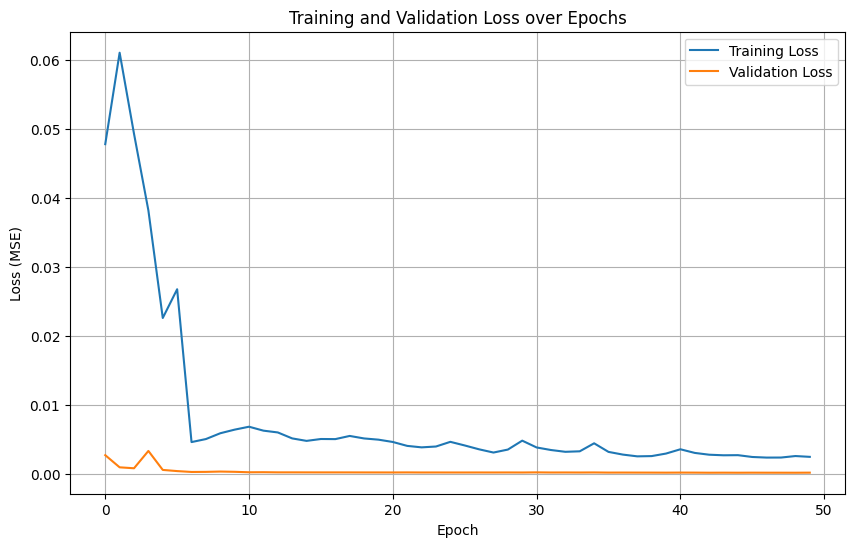

In [6]:
# 5. Train the Model

# Set up the optimizer and loss function.
LEARNING_RATE = 0.001
EPOCHS = 50 # Number of training epochs

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_function = torch.nn.MSELoss() # Mean Squared Error for regression

# Lists to store loss and accuracy (or R2) for plotting
train_losses = []
val_losses = []

print(f"\n--- Starting Model Training ---")
print(f"Training for {EPOCHS} epochs with Learning Rate: {LEARNING_RATE}")

for i in range(EPOCHS):
    # --- Training Loop ---
    model.train() # Set the model to training mode
    batch_train_losses = []
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device) # Move data to device (CPU/GPU)

        optimizer.zero_grad() # Clear gradients from previous step

        output = model(batch_X) # Forward pass

        loss = loss_function(output, batch_y) # Calculate loss
        loss.backward() # Backward pass (compute gradients)

        optimizer.step() # Update model parameters

        batch_train_losses.append(loss.item())

    avg_train_loss = np.mean(batch_train_losses)
    train_losses.append(avg_train_loss)

    # --- Validation Loop ---
    model.eval() # Set the model to evaluation mode (disables dropout, etc.)
    batch_val_losses = []
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for batch_X_val, batch_y_val in val_loader:
            batch_X_val, batch_y_val = batch_X_val.to(device), batch_y_val.to(device)

            val_output = model(batch_X_val)
            val_loss = loss_function(val_output, batch_y_val)
            batch_val_losses.append(val_loss.item())

    avg_val_loss = np.mean(batch_val_losses)
    val_losses.append(avg_val_loss)

    # Print progress
    if (i+1) % 5 == 0 or i == 0: # Print every 5 epochs or on the first epoch
        print(f"Epoch {i+1}/{EPOCHS}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

print("\n--- Training Complete ---")

# Plotting training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


**Observations clés sur l'entraînement**


1. Diminution rapide de la Perte

* La Train Loss (perte sur les données d'entraînement) diminue de manière significative, passant de 0.061795 à l'époque 1 à 0.002633 à l'époque 50. Cela indique que le modèle apprend efficacement à s'adapter aux données d'entraînement.

* La Val Loss (perte sur les données de validation) diminue également drastiquement, passant de 0.003483 à 0.000184. C'est un excellent signe.


2. Excellente généralisation

* La Val Loss est constamment beaucoup plus basse que la Train Loss tout au long de l'entraînement. C'est un indicateur fort que le modèle ne sur-apprend pas et qu'il généralise très bien aux données qu'il n'a pas vues pendant l'entraînement. Une perte de validation aussi faible (autour de 0.0002) est très prometteuse pour la précision future.

De plus, la Val Loss est remarquablement stable vers la fin de l'entraînement, suggérant que le modèle a convergé et atteint une performance optimale sur l'ensemble de validation avec le nombre d'époques défini.


3. Temps d'entraînement : le modèle a été entraîné pendant 50 époques. Pour la rapidité de la perte de validation, il semble que ce nombre soit suffisant pour une bonne convergence.

**6. Evaluate the Model**

La dernière étape consiste à évaluer les performances du modèle sur le jeu de test, en utilisant le R2 score pour une tâche de régression.


--- Model Evaluation on Test Set ---
R² Score on Test Set: 0.8707


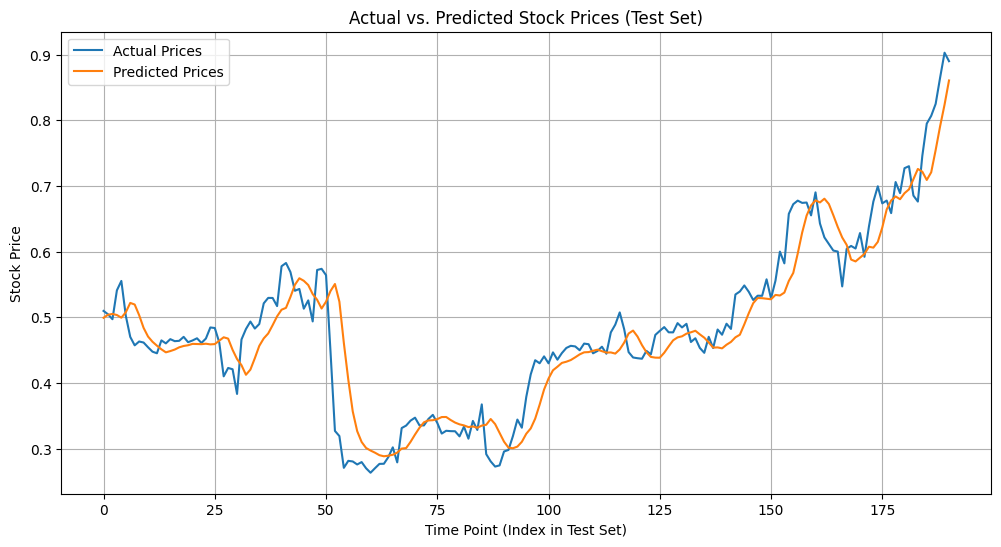


Scalers saved: 'scaler_X.pkl' and 'scaler_y.pkl'
Trained model saved to: 'lstm_stock_predictor.pth'


In [7]:
# 6. Evaluate the Model

model.eval() # Set the model to evaluation mode
test_predictions = []
true_targets = []

with torch.no_grad():
    for batch_X_test, batch_y_test in test_loader:
        batch_X_test = batch_X_test.to(device)
        test_output = model(batch_X_test)

        # Move predictions and true targets back to CPU for evaluation
        test_predictions.extend(test_output.cpu().numpy())
        true_targets.extend(batch_y_test.cpu().numpy())

# Convert lists to numpy arrays
test_predictions = np.array(test_predictions)
true_targets = np.array(true_targets)

# Inverse transform the scaled predictions and true targets back to original scale
# This is crucial for interpreting the R2 score in the original price range.
test_predictions_original_scale = scaler_y.inverse_transform(test_predictions)
true_targets_original_scale = scaler_y.inverse_transform(true_targets)

# Calculate the R² score to evaluate the model’s performance on the test set.
r2 = r2_score(true_targets_original_scale, test_predictions_original_scale)

print(f"\n--- Model Evaluation on Test Set ---")
print(f"R² Score on Test Set: {r2:.4f}")

# Visualize actual vs. predicted prices
plt.figure(figsize=(12, 6))
plt.plot(true_targets_original_scale, label='Actual Prices')
plt.plot(test_predictions_original_scale, label='Predicted Prices')
plt.title('Actual vs. Predicted Stock Prices (Test Set)')
plt.xlabel('Time Point (Index in Test Set)')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()


# Save the scaler object for future predictions.
# It's good practice to save the scalers so you can preprocess new data and inverse-transform predictions consistently.
import joblib # Often used for saving sklearn objects

scaler_X_filename = 'scaler_X.pkl'
scaler_y_filename = 'scaler_y.pkl'
joblib.dump(scaler_X, scaler_X_filename)
joblib.dump(scaler_y, scaler_y_filename)

print(f"\nScalers saved: '{scaler_X_filename}' and '{scaler_y_filename}'")

# Optionally, save the trained PyTorch model state dictionary
model_filename = 'lstm_stock_predictor.pth'
torch.save(model.state_dict(), model_filename)
print(f"Trained model saved to: '{model_filename}'")



1. R2 Score on Test Set: 0.8707

* C'est le point le plus important. Le score R2
  (coefficient de détermination) est une métrique cruciale pour les modèles de régression. Il varie entre −infty et 1.

* Un score de 1 indique que le modèle explique parfaitement la variance de la variable cible.

* Un score de 0 indique que le modèle n'explique aucune variance et fait aussi bien qu'une simple moyenne de la cible.

* Un score négatif indique que le modèle est pire qu'une simple moyenne.

* Le score de 0.8707 est excellent. Cela signifie que votre modèle LSTM est capable d'expliquer environ 87% de la variance des prix de clôture sur l'ensemble de test, des données qu'il n'a jamais vues. Pour la prédiction des prix d'actions (notoirement difficile), c'est une très bonne performance initiale. Cela démontre que le modèle a appris des patterns significatifs dans nos données de séries temporelles.


2. Scalers saved: 'scaler_X.pkl' and 'scaler_y.pkl'

* C'est une excellente pratique ! En sauvegardant vos objets MinMaxScaler (utilisant joblib), vous vous assurez de pouvoir :

> Normaliser de nouvelles données de la même manière que celles sur lesquelles le modèle a été entraîné.

> Inverser les prédictions de notre modèle (qui sont dans la plage [0,1]) pour les ramener à l'échelle des prix d'actions réels. Sans ces scalers, les prédictions seraient inutilisables.


3. Trained model saved to: 'lstm_stock_predictor.pth'

* Sauvegarder le modèle entraîné (model.state_dict()) est également crucial. Le fichier .pth contient les poids et les biais appris par le réseau neuronal.

Cela vous permet de recharger le modèle plus tard sans avoir à le ré-entraîner, et de l'utiliser pour faire de nouvelles prédictions ou pour le déployer.


**Conclusion du Défi :**

Prédiction des prix des actions avec un LSTM rendu possible :

* Gestion du prétraitement des séries temporelles (décalage, séquences).

*  MinMaxScaler pour la normalisation.

* Modèle LSTM robuste entraîné avec PyTorch.

* Modèle évalué en utilisant le score R2
  sur un ensemble de test chronologiquement séparé.

* Sauvegarde des scalers et du modèle.


Un R2 de 0.87 est un excellent point de départ pour ce type de problème.

**Analyse du Graphique : Prédictions Réelles vs. Prédites sur l'Ensemble de Test**

1. Chevauchement et respect du rythme ("dents de scie") :

* C'est la preuve la plus concrète que le modèle capte bien la tendance générale et la volatilité des prix. Le fait que les deux courbes se chevauchent et suivent le même rythme de "dents de scie" montre que le modèle n'est pas "à côté de la plaque" mais qu'il réagit aux mêmes mouvements de marché que les prix réels.

* C'est une caractéristique clé pour un modèle de prédiction de séries temporelles : il doit suivre les hausses et les baisses.


2. Proximité des courbes ("se chevauchent et se croisent plusieurs fois") :

* Cela signifie que les erreurs de prédiction sont faibles. Le modèle prédit des valeurs très proches des prix réels, ce qui est validé par votre excellent score R2 de 0.8707. Une telle proximité est un signe de haute précision.


3. Légère dominance de la courbe bleue ("proportionnellement, la courbe bleue est plus souvent au-dessus") :

* Cette observation est intéressante. Si la courbe bleue (prix réels) est légèrement plus souvent au-dessus de la courbe orange (prix prédits), cela pourrait suggérer une légère sous-estimation systématique des prix par le modèle. C'est une nuance qu'on peut chercher à corriger dans des itérations futures du modèle, mais elle est souvent minime et acceptable pour un premier jet.


4. Phases de croissance/décroissance :

Des phases distinctes de mouvement des prix sur l'ensemble de test (0-50, 50-100, puis forte croissance). Le fait que les deux courbes suivent ces phases avec une telle fidélité (départ à (0, 0.5), (50, 0.58), puis (60, 0.26 env), (75, 0.35), (100, 0.43), et la forte croissance vers 0.9) est une démonstration claire de la capacité du LSTM à apprendre et à reproduire la dynamique des séries temporelles.

**Conclusion Générale**


Ce graphique confirme visuellement le succès du modèle. Les prédictions sont très proches des valeurs réelles et le modèle est capable de suivre les tendances du marché, qu'elles soient à la hausse ou à la baisse. Un R2 de 0.8707, appuyé par cette excellente visualisation, indique que le modèle de prédiction de prix d'actions est très performant pour ce dataset.